In [5]:
!pip install pylidc

   ---------------------------------------- 0.0/5.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/5.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/5.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/5.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/5.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/5.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/5.6 MB 325.1 kB/s eta 0:00:18
   ---------------------------------------- 0.0/5.6 MB 325.1 kB/s eta 0:00:18
   ---------------------------------------- 0.0/5.6 MB 325.1 kB/s eta 0:00:18
   ---------------------------------------- 0.0/5.6 MB 325.1 kB/s eta 0:00:18
   ---------------------------------------- 0.0/5.6 MB 325.1 kB/s eta 0:00:18
   ---------------------------------------- 0.0/5.6 MB 325.1 kB/s eta 0:00:18
   ---------------------------------------- 0.0/5.6 MB 103.4 kB/s eta 0:00:54
   -------------------------------------

2025-04-12 10:40:27,004:INFO:Calling getSeries with parameters {'Collection': 'LIDC-IDRI'}
2025-04-12 10:40:46,453:INFO:Downloading 16 out of 16 Series Instance UIDs (scans).
2025-04-12 10:40:46,455:INFO:Directory './lidc_subset' already exists.
2025-04-12 10:40:46,456:WARNING:Series 1.3.6.1.4.1.14519.5.2.1.6279.6001.141365756818074696859567662357 already downloaded and unzipped.
2025-04-12 10:40:46,457:WARNING:Series 1.3.6.1.4.1.14519.5.2.1.6279.6001.179049373636438705059720603192 already downloaded and unzipped.
2025-04-12 10:40:46,457:WARNING:Series 1.3.6.1.4.1.14519.5.2.1.6279.6001.493562949900213760403901722902 already downloaded and unzipped.
2025-04-12 10:40:46,458:WARNING:Series 1.3.6.1.4.1.14519.5.2.1.6279.6001.619372068417051974713149104919 already downloaded and unzipped.
2025-04-12 10:40:46,459:WARNING:Series 1.2.276.0.7230010.3.1.3.0.89314.1553284067.990548 already downloaded and unzipped.
2025-04-12 10:40:46,460:WARNING:Series 1.2.276.0.7230010.3.1.3.0.89316.1553284071.47

Available keys in series_data[0]: dict_keys(['SeriesInstanceUID', 'StudyInstanceUID', 'Modality', 'SeriesDate', 'BodyPartExamined', 'SeriesNumber', 'AnnotationsFlag', 'Collection', 'PatientID', 'Manufacturer', 'ManufacturerModelName', 'SoftwareVersions', 'ImageCount', 'TimeStamp', 'LicenseName', 'LicenseURI', 'CollectionURI', 'FileSize', 'DateReleased', 'StudyDate'])
Downloaded series to: ./lidc_subset
Series UIDs for LIDC-IDRI-0001: ['1.3.6.1.4.1.14519.5.2.1.6279.6001.141365756818074696859567662357', '1.3.6.1.4.1.14519.5.2.1.6279.6001.179049373636438705059720603192', '1.2.276.0.7230010.3.1.3.0.89314.1553284067.990548', '1.2.276.0.7230010.3.1.3.0.89316.1553284071.471973', '1.2.276.0.7230010.3.1.3.0.89355.1553284075.626419', '1.2.276.0.7230010.3.1.3.0.89358.1553284079.860324', '1.2.276.0.7230010.3.1.3.0.89359.1553284081.678382', '1.2.276.0.7230010.3.1.3.0.89356.1553284077.719168', '1.2.276.0.7230010.3.1.3.0.89315.1553284069.532969', '1.2.276.0.7230010.3.1.3.0.89354.1553284073.397598']
S

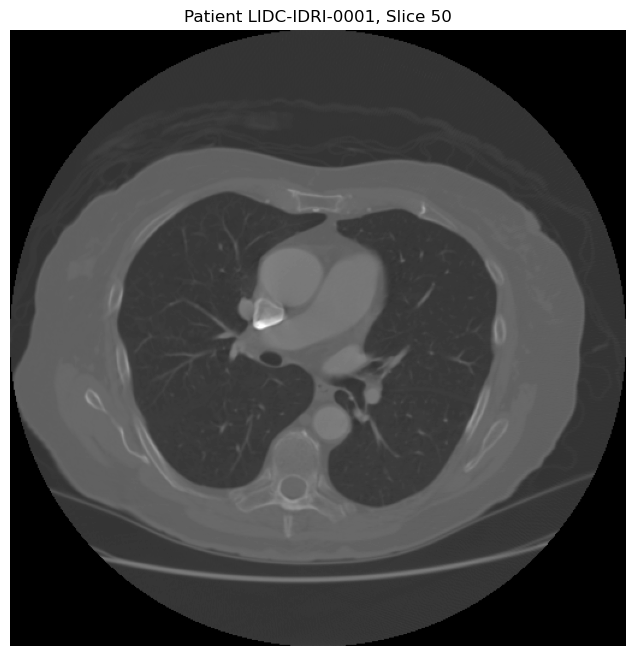

In [7]:
import os
from tcia_utils import nbia
import pydicom
import matplotlib.pyplot as plt
import numpy as np

# Define download directory
download_dir = "./lidc_subset"
os.makedirs(download_dir, exist_ok=True)

# List of patient IDs to download
patient_ids = [
    "LIDC-IDRI-0001",
    "LIDC-IDRI-0002"
]

# Step 1: Query TCIA for the LIDC-IDRI collection
series_data = nbia.getSeries(collection="LIDC-IDRI")

# Debugging: Print the keys of the first series
if series_data:
    print("Available keys in series_data[0]:", series_data[0].keys())
else:
    print("No series data returned. Check collection name or API access.")
    exit()

# Step 2: Filter series for the patients
series_to_download = [s for s in series_data if s.get("PatientID") in patient_ids]

# Step 3: Download the filtered series
if series_to_download:
    series_uids = [s["SeriesInstanceUID"] for s in series_to_download]
    nbia.downloadSeries(series_uids, input_type="list", path=download_dir)
    print(f"Downloaded series to: {download_dir}")
else:
    print("No matching series found for the specified patient IDs.")
    exit()

# Step 4: Map series UIDs to patient IDs
series_dict = {s["SeriesInstanceUID"]: s["PatientID"] for s in series_to_download}
patient_series_uids = [uid for uid, pid in series_dict.items() if pid == "LIDC-IDRI-0001"]

# Debugging: Print series UIDs for LIDC-IDRI-0001
print("Series UIDs for LIDC-IDRI-0001:", patient_series_uids)

# Load DICOM files for LIDC-IDRI-0001 (only CT images)
dicom_files = []
for root, _, files in os.walk(download_dir):
    for file in files:
        if file.endswith(".dcm"):
            full_path = os.path.join(root, file)
            # Check if the file's directory contains any series UID for LIDC-IDRI-0001
            if any(uid in root for uid in patient_series_uids):
                try:
                    ds = pydicom.dcmread(full_path, stop_before_pixels=True)
                    # Filter for CT images (SOP Class UID for CT Image Storage)
                    if ds.SOPClassUID == "1.2.840.10008.5.1.4.1.1.2":
                        ds_full = pydicom.dcmread(full_path)  # Reload with pixel data
                        dicom_files.append(ds_full)
                    else:
                        print(f"Skipped {full_path}: Not a CT image (SOPClassUID={ds.SOPClassUID})")
                except Exception as e:
                    print(f"Failed to load {full_path}: {e}")

# Debugging: Print number of CT DICOM files found
print(f"Found {len(dicom_files)} CT DICOM files for LIDC-IDRI-0001.")

if not dicom_files:
    print("No CT DICOM files found for LIDC-IDRI-0001. Check series UID mapping or file structure.")
    exit()

# Sort by InstanceNumber or SliceLocation
dicom_files.sort(key=lambda x: float(x.get("InstanceNumber", x.get("SliceLocation", 0))))

# Create 3D volume
volume = np.stack([s.pixel_array for s in dicom_files], axis=-1)

# Step 5: Visualize a sample slice (no annotations yet)
slice_num = 50  # Adjust as needed
plt.figure(figsize=(8, 8))
plt.imshow(volume[:, :, slice_num], cmap='gray')
plt.title(f"Patient LIDC-IDRI-0001, Slice {slice_num}")
plt.axis('off')
plt.savefig('lidc_slice_visualization_pydicom.png')
print("Visualization saved as 'lidc_slice_visualization_pydicom.png'")

In [29]:
!pip install dash_bootstrap_components
!pip install dash

   ---------------------------------------- 0.0/202.5 kB ? eta -:--:--
   -- ------------------------------------- 10.2/202.5 kB ? eta -:--:--
   --- ----------------------------------- 20.5/202.5 kB 330.3 kB/s eta 0:00:01
   ------- ------------------------------- 41.0/202.5 kB 281.8 kB/s eta 0:00:01
   ----------------- --------------------- 92.2/202.5 kB 525.1 kB/s eta 0:00:01
   ----------------- --------------------- 92.2/202.5 kB 525.1 kB/s eta 0:00:01
   ---------------------------- --------- 153.6/202.5 kB 612.6 kB/s eta 0:00:01
   -------------------------------------- 202.5/202.5 kB 725.3 kB/s eta 0:00:00


LIDC-IDRI Nodule Visualization Pipeline
Found DICOM series at: .\LIDC-IDRI-0001\01-01-2000-NA-NA-30178\3000566.000000-NA-03192 (133 files)
Found annotation file: .\LIDC-IDRI-0001\01-01-2000-NA-NA-30178\3000566.000000-NA-03192\069.xml


Loading DICOM: 100%|██████████| 133/133 [00:00<00:00, 658.63it/s]


Parsed 4 nodules with 32 contours
Showing 5 of 9 annotated slices:


AttributeError: 'Polygon' object has no attribute 'copy'

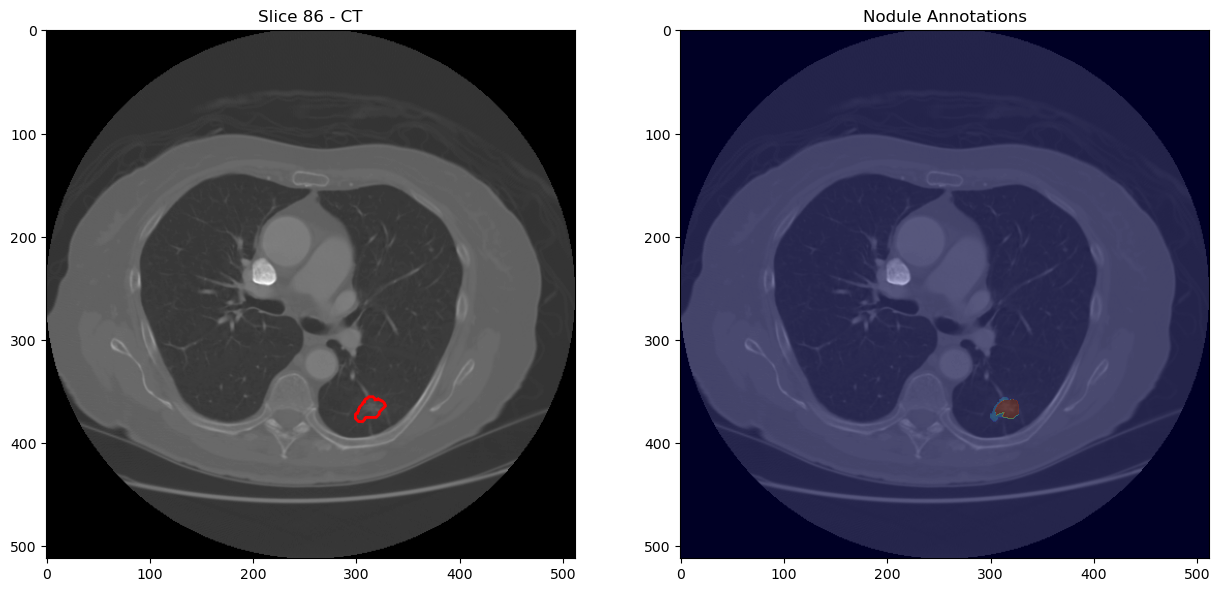

In [57]:
import os
import pydicom
import numpy as np
import matplotlib.pyplot as plt
import xml.etree.ElementTree as ET
import matplotlib.patches as patches
from tqdm import tqdm
import warnings

# Suppress warnings
warnings.filterwarnings("ignore", category=UserWarning, module='pydicom')

# Configuration
BASE_DIR = "."  # Main folder containing patient data
PATIENT_ID = "LIDC-IDRI-0001"  # Patient folder to process
OUTPUT_DIR = "LIDC_output"  # Output directory
os.makedirs(OUTPUT_DIR, exist_ok=True)

class LIDC_Processor:
    def __init__(self, patient_id=PATIENT_ID):
        self.patient_id = patient_id
        self.volume = None
        self.dicom_files = []
        self.metadata = []
        self.nodules = []
        self.segmentation_mask = None
        self.dicom_dir = None
        self.annotation_file = None

    def find_dicom_series(self):
        """Locate DICOM series in patient folder"""
        patient_dir = os.path.join(BASE_DIR, self.patient_id)
        if not os.path.exists(patient_dir):
            print(f"Error: Patient directory not found at {patient_dir}")
            return False

        for study in os.listdir(patient_dir):
            study_path = os.path.join(patient_dir, study)
            if os.path.isdir(study_path):
                for series in os.listdir(study_path):
                    series_path = os.path.join(study_path, series)
                    dcm_files = [f for f in os.listdir(series_path) if f.lower().endswith('.dcm')]
                    if len(dcm_files) > 100:  # Found complete series
                        self.dicom_dir = series_path
                        print(f"Found DICOM series at: {self.dicom_dir} ({len(dcm_files)} files)")
                        return True
        
        print("Error: No complete DICOM series found")
        return False

    def find_annotation_file(self):
        """Locate XML annotation file"""
        patient_dir = os.path.join(BASE_DIR, self.patient_id)
        for root, _, files in os.walk(patient_dir):
            for f in files:
                if f.lower().endswith('.xml'):
                    self.annotation_file = os.path.join(root, f)
                    print(f"Found annotation file: {self.annotation_file}")
                    return True
        print("Warning: No annotation file found")
        return False

    def load_dicom_series(self):
        """Load and sort DICOM files"""
        try:
            dcm_files = [f for f in os.listdir(self.dicom_dir) if f.lower().endswith('.dcm')]
            self.dicom_files = []
            self.metadata = []

            for f in tqdm(sorted(dcm_files), desc="Loading DICOM"):
                ds = pydicom.dcmread(os.path.join(self.dicom_dir, f))
                if hasattr(ds, 'pixel_array'):
                    self.dicom_files.append(ds)
                    self.metadata.append({
                        "SOPInstanceUID": ds.SOPInstanceUID,
                        "position": ds.ImagePositionPatient,
                        "spacing": ds.PixelSpacing,
                        "thickness": ds.SliceThickness
                    })

            # Sort by Z-position
            self.dicom_files.sort(key=lambda x: float(x.ImagePositionPatient[2]))
            self.metadata.sort(key=lambda x: float(x["position"][2]))

            # Create 3D volume
            self.volume = np.stack([ds.pixel_array for ds in self.dicom_files])
            return True

        except Exception as e:
            print(f"Error loading DICOM: {str(e)}")
            return False

    def parse_annotations(self):
        """Parse XML annotations with namespace support"""
        if not self.annotation_file:
            return

        try:
            ns = {'ns': 'http://www.nih.gov'}
            tree = ET.parse(self.annotation_file)
            root = tree.getroot()
            uid_to_slice = {m["SOPInstanceUID"]: i for i, m in enumerate(self.metadata)}

            self.nodules = []
            for reading in root.findall('.//ns:readingSession', ns):
                for nodule in reading.findall('.//ns:unblindedReadNodule', ns):
                    nodule_id = nodule.find('ns:noduleID', ns).text
                    
                    # Get characteristics
                    chars = nodule.find('ns:characteristics', ns)
                    malignancy = int(chars.find('ns:malignancy', ns).text) if chars is not None else None
                    
                    # Get contours
                    contours = []
                    for roi in nodule.findall('.//ns:roi', ns):
                        sop_uid = roi.find('ns:imageSOP_UID', ns).text
                        if sop_uid in uid_to_slice:
                            points = []
                            for edge in roi.findall('.//ns:edgeMap', ns):
                                x = float(edge.find('ns:xCoord', ns).text)
                                y = float(edge.find('ns:yCoord', ns).text)
                                points.append((x, y))
                            
                            if len(points) > 2:
                                contours.append({
                                    "slice": uid_to_slice[sop_uid],
                                    "points": points
                                })

                    if contours:
                        self.nodules.append({
                            "id": nodule_id,
                            "malignancy": malignancy,
                            "contours": contours
                        })

            print(f"Parsed {len(self.nodules)} nodules with {sum(len(n['contours']) for n in self.nodules)} contours")
            self.create_segmentation_mask()

        except Exception as e:
            print(f"Error parsing XML: {str(e)}")

    def create_segmentation_mask(self):
        """Create 3D mask from contours"""
        if not self.nodules:
            return

        self.segmentation_mask = np.zeros_like(self.volume, dtype=np.uint8)
        for i, nodule in enumerate(self.nodules, 1):
            for contour in nodule["contours"]:
                slice_idx = contour["slice"]
                points = contour["points"]
                
                # Create polygon mask
                from matplotlib.path import Path
                y, x = np.mgrid[:self.volume.shape[1], :self.volume.shape[2]]
                coords = np.vstack((x.flatten(), y.flatten())).T
                mask = Path(points).contains_points(coords)
                mask = mask.reshape((self.volume.shape[1], self.volume.shape[2]))
                self.segmentation_mask[slice_idx][mask] = i

    def get_annotated_slices(self):
        """Return sorted list of slices with nodules"""
        slices = set()
        for nodule in self.nodules:
            for contour in nodule["contours"]:
                slices.add(contour["slice"])
        return sorted(slices)

    def visualize_annotated_slices(self, max_slices=5):
        """Visualize slices with nodule annotations"""
        if not self.nodules:
            print("No nodules found to visualize")
            return

        annotated_slices = self.get_annotated_slices()
        print(f"Showing {min(max_slices, len(annotated_slices))} of {len(annotated_slices)} annotated slices:")

        for slice_idx in annotated_slices[:max_slices]:
            fig, ax = plt.subplots(1, 2, figsize=(15, 8))
            
            # Show CT slice
            ax[0].imshow(self.volume[slice_idx], cmap='gray')
            ax[0].set_title(f"Slice {slice_idx} - CT")
            
            # Show overlay
            ax[1].imshow(self.volume[slice_idx], cmap='gray')
            if self.segmentation_mask is not None:
                ax[1].imshow(self.segmentation_mask[slice_idx], 
                            cmap='jet', alpha=0.3)
            ax[1].set_title("Nodule Annotations")

            # Draw contours and labels
            for nodule in self.nodules:
                for contour in nodule["contours"]:
                    if contour["slice"] == slice_idx:
                        poly = patches.Polygon(
                            contour["points"],
                            closed=True,
                            fill=False,
                            edgecolor='red',
                            linewidth=2
                        )
                        ax[0].add_patch(poly)
                        ax[1].add_patch(poly.copy())
                        
                        # Add label
                        centroid = np.mean(contour["points"], axis=0)
                        ax[1].text(
                            centroid[0], centroid[1],
                            f"{nodule['id']}\nM:{nodule['malignancy']}",
                            color='yellow',
                            fontsize=10,
                            ha='center',
                            va='center'
                        )

            plt.tight_layout()
            output_path = os.path.join(OUTPUT_DIR, f'slice_{slice_idx:03d}.png')
            plt.savefig(output_path, bbox_inches='tight', dpi=150)
            plt.close()
            print(f"Saved: {output_path}")

def main():
    print("LIDC-IDRI Nodule Visualization Pipeline")
    print("="*50)
    
    processor = LIDC_Processor()
    
    if not processor.find_dicom_series():
        return
    processor.find_annotation_file()
    
    if not processor.load_dicom_series():
        return
    
    processor.parse_annotations()
    processor.visualize_annotated_slices(max_slices=5)

if __name__ == "__main__":
    main()

LIDC-IDRI Enhanced Visualization Pipeline
Found DICOM series at: .\LIDC-IDRI-0001\01-01-2000-NA-NA-30178\3000566.000000-NA-03192 (133 files)
Found annotation file: .\LIDC-IDRI-0001\01-01-2000-NA-NA-30178\3000566.000000-NA-03192\069.xml


Loading DICOM: 100%|██████████| 133/133 [00:00<00:00, 371.52it/s]


Parsed 4 nodules with 32 contours
Displaying 3 enhanced slices


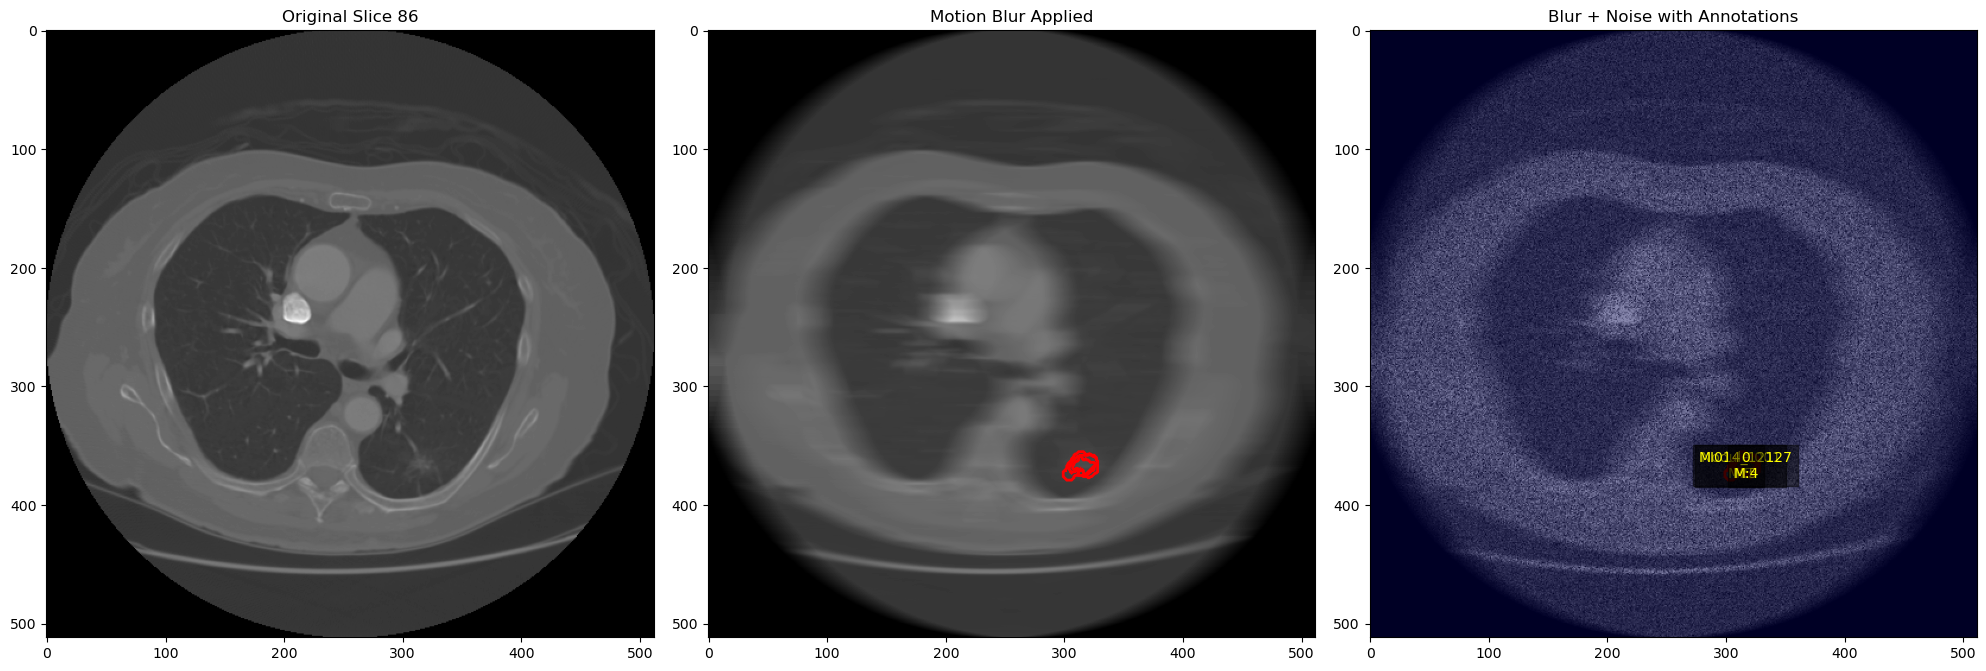

Saved enhanced image: LIDC_output\enhanced_086.png


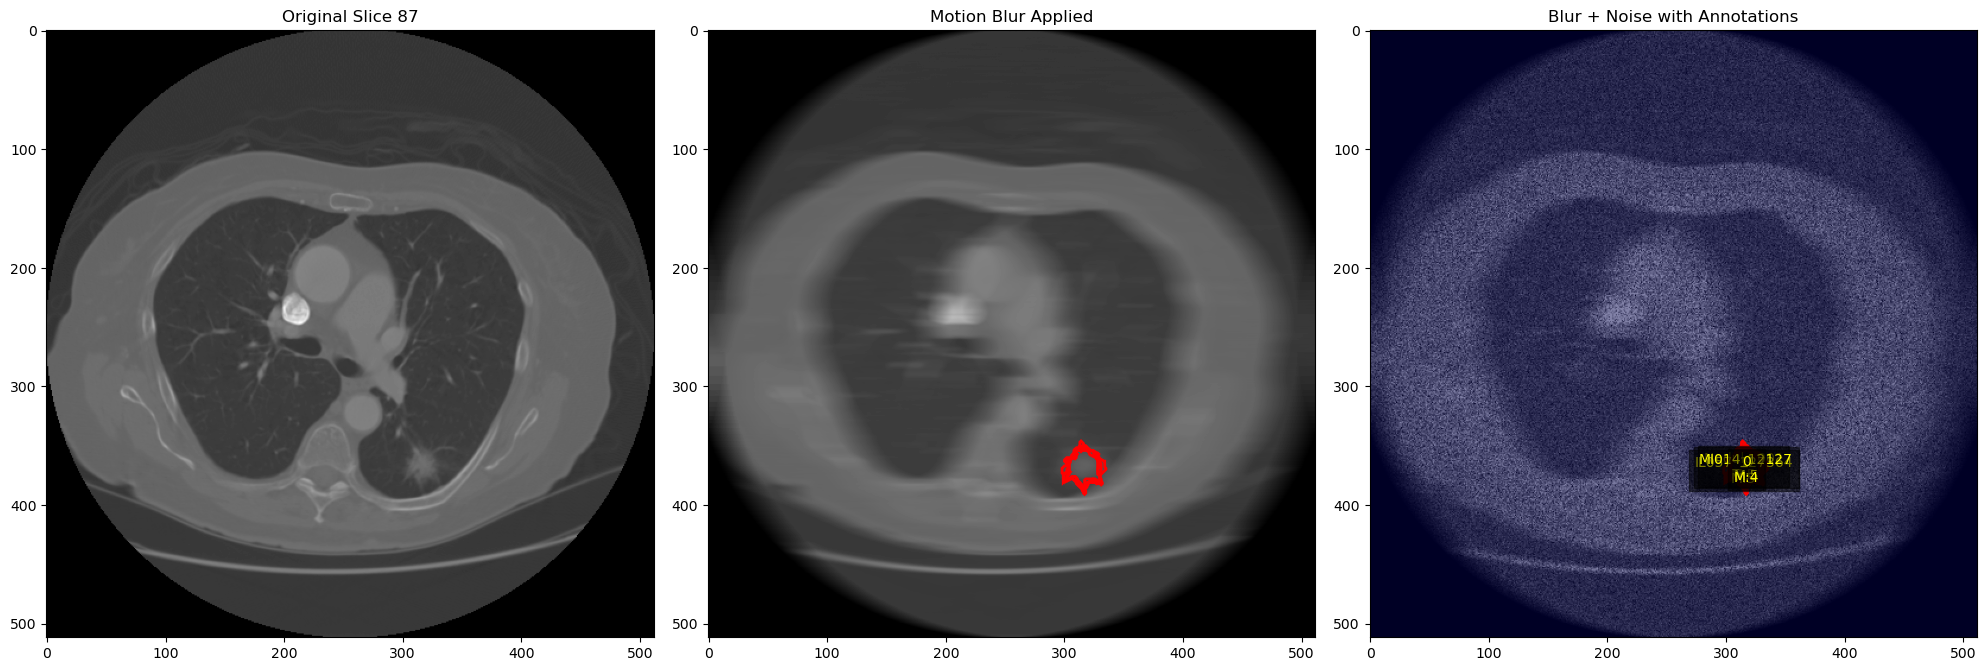

Saved enhanced image: LIDC_output\enhanced_087.png


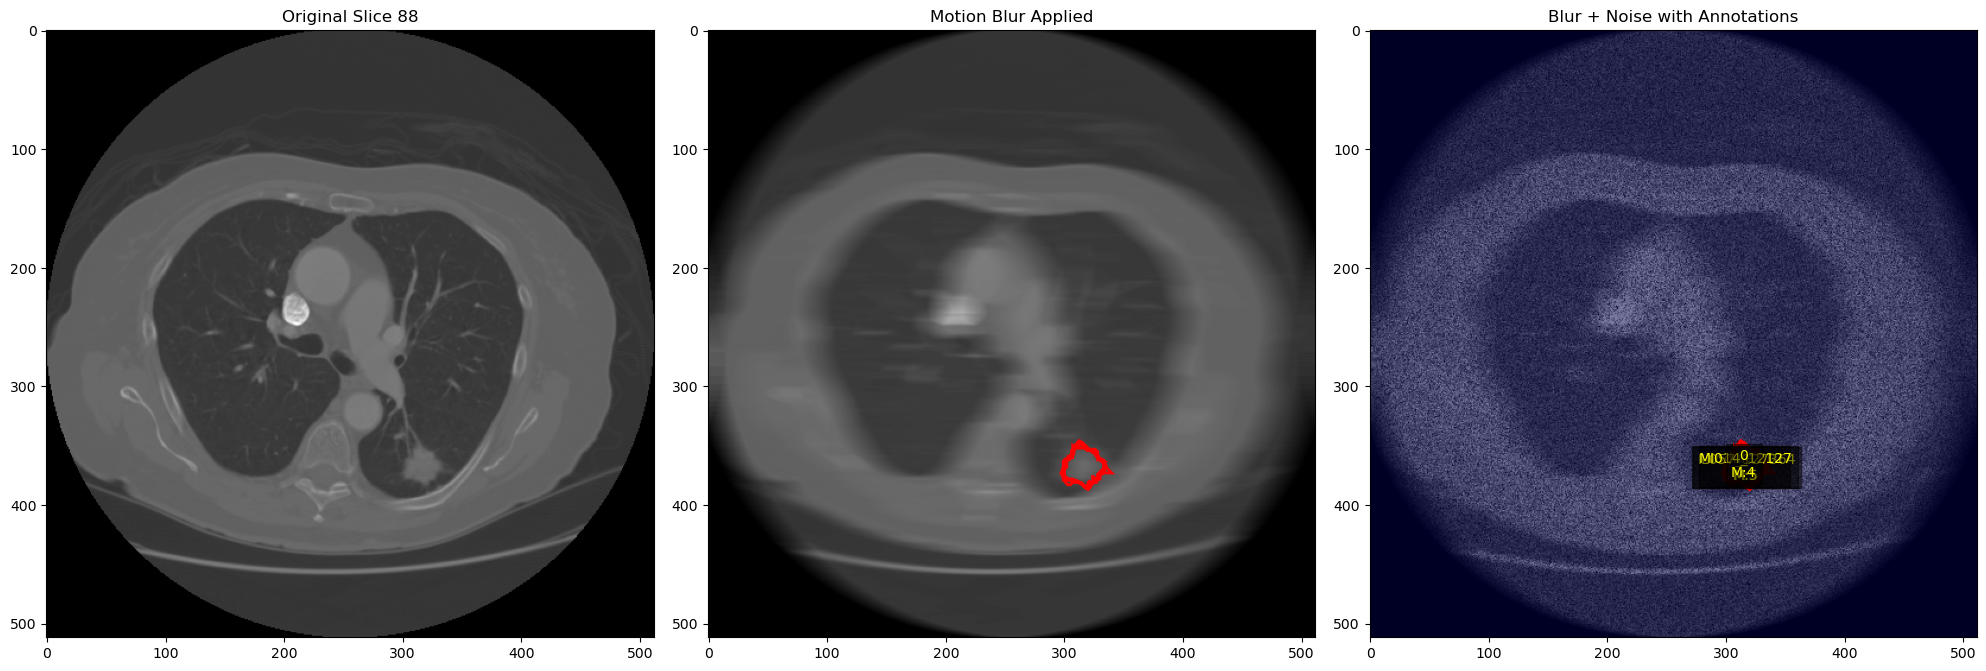

Saved enhanced image: LIDC_output\enhanced_088.png


In [69]:
import os
import pydicom
import numpy as np
import matplotlib.pyplot as plt
import xml.etree.ElementTree as ET
import matplotlib.patches as patches
from tqdm import tqdm
import warnings
from scipy.ndimage import convolve

# Suppress warnings
warnings.filterwarnings("ignore", category=UserWarning, module='pydicom')

# Configuration
BASE_DIR = "."  # Main folder containing patient data
PATIENT_ID = "LIDC-IDRI-0001"  # Patient folder to process
OUTPUT_DIR = "LIDC_output"  # Output directory
os.makedirs(OUTPUT_DIR, exist_ok=True)

class LIDC_Processor:
    def __init__(self, patient_id=PATIENT_ID):
        self.patient_id = patient_id
        self.volume = None
        self.dicom_files = []
        self.metadata = []
        self.nodules = []
        self.segmentation_mask = None
        self.dicom_dir = None
        self.annotation_file = None

    def find_dicom_series(self):
        """Locate DICOM series in patient folder"""
        patient_dir = os.path.join(BASE_DIR, self.patient_id)
        if not os.path.exists(patient_dir):
            print(f"Error: Patient directory not found at {patient_dir}")
            return False

        for study in os.listdir(patient_dir):
            study_path = os.path.join(patient_dir, study)
            if os.path.isdir(study_path):
                for series in os.listdir(study_path):
                    series_path = os.path.join(study_path, series)
                    dcm_files = [f for f in os.listdir(series_path) if f.lower().endswith('.dcm')]
                    if len(dcm_files) > 100:  # Found complete series
                        self.dicom_dir = series_path
                        print(f"Found DICOM series at: {self.dicom_dir} ({len(dcm_files)} files)")
                        return True
        
        print("Error: No complete DICOM series found")
        return False

    def find_annotation_file(self):
        """Locate XML annotation file"""
        patient_dir = os.path.join(BASE_DIR, self.patient_id)
        for root, _, files in os.walk(patient_dir):
            for f in files:
                if f.lower().endswith('.xml'):
                    self.annotation_file = os.path.join(root, f)
                    print(f"Found annotation file: {self.annotation_file}")
                    return True
        print("Warning: No annotation file found")
        return False

    def load_dicom_series(self):
        """Load and sort DICOM files"""
        try:
            dcm_files = [f for f in os.listdir(self.dicom_dir) if f.lower().endswith('.dcm')]
            self.dicom_files = []
            self.metadata = []

            for f in tqdm(sorted(dcm_files), desc="Loading DICOM"):
                ds = pydicom.dcmread(os.path.join(self.dicom_dir, f))
                if hasattr(ds, 'pixel_array'):
                    self.dicom_files.append(ds)
                    self.metadata.append({
                        "SOPInstanceUID": ds.SOPInstanceUID,
                        "position": ds.ImagePositionPatient,
                        "spacing": ds.PixelSpacing,
                        "thickness": ds.SliceThickness
                    })

            # Sort by Z-position
            self.dicom_files.sort(key=lambda x: float(x.ImagePositionPatient[2]))
            self.metadata.sort(key=lambda x: float(x["position"][2]))

            # Create 3D volume
            self.volume = np.stack([ds.pixel_array for ds in self.dicom_files])
            return True

        except Exception as e:
            print(f"Error loading DICOM: {str(e)}")
            return False

    def parse_annotations(self):
        """Parse XML annotations with namespace support"""
        if not self.annotation_file:
            return

        try:
            ns = {'ns': 'http://www.nih.gov'}
            tree = ET.parse(self.annotation_file)
            root = tree.getroot()
            uid_to_slice = {m["SOPInstanceUID"]: i for i, m in enumerate(self.metadata)}

            self.nodules = []
            for reading in root.findall('.//ns:readingSession', ns):
                for nodule in reading.findall('.//ns:unblindedReadNodule', ns):
                    nodule_id = nodule.find('ns:noduleID', ns).text
                    
                    # Get characteristics
                    chars = nodule.find('ns:characteristics', ns)
                    malignancy = int(chars.find('ns:malignancy', ns).text) if chars is not None else None
                    
                    # Get contours
                    contours = []
                    for roi in nodule.findall('.//ns:roi', ns):
                        sop_uid = roi.find('ns:imageSOP_UID', ns).text
                        if sop_uid in uid_to_slice:
                            points = []
                            for edge in roi.findall('.//ns:edgeMap', ns):
                                x = float(edge.find('ns:xCoord', ns).text)
                                y = float(edge.find('ns:yCoord', ns).text)
                                points.append((x, y))
                            
                            if len(points) > 2:
                                contours.append({
                                    "slice": uid_to_slice[sop_uid],
                                    "points": points
                                })

                    if contours:
                        self.nodules.append({
                            "id": nodule_id,
                            "malignancy": malignancy,
                            "contours": contours  # Fixed typo from original
                        })

            print(f"Parsed {len(self.nodules)} nodules with {sum(len(n['contours']) for n in self.nodules)} contours")
            self.create_segmentation_mask()

        except Exception as e:
            print(f"Error parsing XML: {str(e)}")

    def create_segmentation_mask(self):
        """Create 3D mask from contours"""
        if not self.nodules:
            return

        self.segmentation_mask = np.zeros_like(self.volume, dtype=np.uint8)
        for i, nodule in enumerate(self.nodules, 1):
            for contour in nodule["contours"]:
                slice_idx = contour["slice"]
                points = contour["points"]
                
                # Create polygon mask
                from matplotlib.path import Path
                y, x = np.mgrid[:self.volume.shape[1], :self.volume.shape[2]]
                coords = np.vstack((x.flatten(), y.flatten())).T
                mask = Path(points).contains_points(coords)
                mask = mask.reshape((self.volume.shape[1], self.volume.shape[2]))
                self.segmentation_mask[slice_idx][mask] = i

    def get_annotated_slices(self):
        """Return sorted list of slices with nodules"""
        slices = set()
        for nodule in self.nodules:
            for contour in nodule["contours"]:
                slices.add(contour["slice"])
        return sorted(slices)

    def apply_motion_blur(self, image, kernel_size=30):
        """Apply strong horizontal motion blur"""
        kernel = np.zeros((kernel_size, kernel_size))
        kernel[kernel_size//2, :] = np.ones(kernel_size)
        kernel /= kernel_size
        blurred = convolve(image, kernel, mode='reflect')
        return np.clip(blurred, image.min(), image.max())

    def apply_speckle_noise(self, image, strength=0.3):
        """Apply visible speckle noise"""
        noise = np.random.randn(*image.shape) * strength
        noisy = image * (1 + noise)
        return np.clip(noisy, image.min(), image.max())

    def normalize_image(self, image):
        """Normalize image to 0-1 range"""
        return (image - image.min()) / (image.max() - image.min())

    def visualize_enhanced_annotations(self, max_slices=5):
        """Visualize slices with clear enhancements and annotations"""
        if not self.nodules:
            print("No nodules found to visualize")
            return

        annotated_slices = self.get_annotated_slices()
        print(f"Displaying {min(max_slices, len(annotated_slices))} enhanced slices")

        for slice_idx in annotated_slices[:max_slices]:
            original = self.volume[slice_idx]
            normalized = self.normalize_image(original)
            
            # Apply enhancements
            blurred = self.apply_motion_blur(normalized, kernel_size=30)
            enhanced = self.apply_speckle_noise(blurred, strength=0.3)
            
            # Create figure
            fig, ax = plt.subplots(1, 3, figsize=(20, 8))
            
            # Original image
            ax[0].imshow(original, cmap='gray', vmin=original.min(), vmax=original.max())
            ax[0].set_title(f"Original Slice {slice_idx}")
            
            # Blurred only
            ax[1].imshow(blurred, cmap='gray', vmin=0, vmax=1)
            ax[1].set_title("Motion Blur Applied")
            
            # Full enhanced with annotations
            ax[2].imshow(enhanced, cmap='gray', vmin=0, vmax=1)
            if self.segmentation_mask is not None:
                ax[2].imshow(self.segmentation_mask[slice_idx], cmap='jet', alpha=0.3)
            ax[2].set_title("Blur + Noise with Annotations")

            # Add contours and labels
            for nodule in self.nodules:
                for contour in nodule["contours"]:
                    if contour["slice"] == slice_idx:
                        for a in ax[1:]:  # Add to enhanced images only
                            poly = patches.Polygon(
                                contour["points"],
                                closed=True,
                                fill=False,
                                edgecolor='red',
                                linewidth=2
                            )
                            a.add_patch(poly)
                        
                        # Add label to annotated version
                        centroid = np.mean(contour["points"], axis=0)
                        ax[2].text(
                            centroid[0], centroid[1],
                            f"{nodule['id']}\nM:{nodule['malignancy']}",
                            color='yellow',
                            fontsize=10,
                            ha='center',
                            va='center',
                            bbox=dict(facecolor='black', alpha=0.5)
                        )

            plt.tight_layout()
            output_path = os.path.join(OUTPUT_DIR, f'enhanced_{slice_idx:03d}.png')
            plt.savefig(output_path, bbox_inches='tight', dpi=150)
            plt.show()
            plt.close()
            print(f"Saved enhanced image: {output_path}")

def main():
    print("LIDC-IDRI Enhanced Visualization Pipeline")
    print("="*50)
    
    processor = LIDC_Processor()
    
    if not processor.find_dicom_series():
        return
    processor.find_annotation_file()
    
    if not processor.load_dicom_series():
        return
    
    processor.parse_annotations()
    processor.visualize_enhanced_annotations(max_slices=3)

if __name__ == "__main__":
    plt.ion()
    main()

In [1]:
import os
import pydicom
import numpy as np
from scipy.ndimage import convolve
import shutil
from tqdm import tqdm
import warnings

# Suppress warnings
warnings.filterwarnings("ignore", category=UserWarning, module='pydicom')

# Configuration
BASE_DIR = "Dataset"  # Original dataset folder
OUTPUT_DIR = "Enhanced_Dataset"  # Output folder (will mirror structure)
os.makedirs(OUTPUT_DIR, exist_ok=True)

class DatasetEnhancer:
    def __init__(self):
        self.processed_count = 0
        self.failed_patients = []

    def apply_motion_blur(self, image, kernel_size=25):
        """Apply horizontal motion blur"""
        kernel = np.zeros((kernel_size, kernel_size))
        kernel[kernel_size//2, :] = np.ones(kernel_size)
        kernel /= kernel_size
        return convolve(image, kernel, mode='reflect')

    def apply_speckle_noise(self, image, strength=0.2):
        """Apply speckle noise"""
        noise = np.random.randn(*image.shape) * strength
        return image * (1 + noise)

    def process_dicom(self, input_path, output_path):
        """Process a single DICOM file"""
        try:
            # Copy original
            shutil.copy2(input_path, output_path)
            
            # Enhance and save
            ds = pydicom.dcmread(input_path)
            img = ds.pixel_array.astype(float)
            
            # Normalize -> Enhance -> Restore original range
            img_norm = (img - img.min()) / (img.max() - img.min())
            enhanced = self.apply_speckle_noise(self.apply_motion_blur(img_norm))
            enhanced = enhanced * (img.max() - img.min()) + img.min()
            
            # Save enhanced version
            ds.PixelData = enhanced.astype(ds.pixel_array.dtype).tobytes()
            base, ext = os.path.splitext(output_path)
            ds.save_as(f"{base}_enhanced{ext}")
            return True
        except Exception as e:
            print(f"Error processing {input_path}: {str(e)}")
            return False

    def process_patient(self, patient_path):
        """Process all files for one patient"""
        patient_success = True
        patient_name = os.path.basename(patient_path)
        
        for root, dirs, files in os.walk(patient_path):
            # Create mirrored directory structure
            rel_path = os.path.relpath(root, BASE_DIR)
            output_dir = os.path.join(OUTPUT_DIR, rel_path)
            os.makedirs(output_dir, exist_ok=True)
            
            # Process DICOM files
            for f in files:
                input_file = os.path.join(root, f)
                output_file = os.path.join(output_dir, f)
                
                if f.lower().endswith('.dcm'):
                    if not self.process_dicom(input_file, output_file):
                        patient_success = False
                else:
                    # Copy non-DICOM files (like XML) unchanged
                    try:
                        shutil.copy2(input_file, output_file)
                    except Exception as e:
                        print(f"Error copying {input_file}: {str(e)}")
                        patient_success = False
        
        # Only delete if processing was fully successful
        if patient_success:
            try:
                shutil.rmtree(patient_path)
                print(f"Successfully processed and removed: {patient_name}")
            except Exception as e:
                print(f"Error removing {patient_name}: {str(e)}")
                self.failed_patients.append(patient_name)
                patient_success = False
        else:
            self.failed_patients.append(patient_name)
            
        return patient_success

    def process_all(self):
        """Process entire dataset"""
        patients = [d for d in os.listdir(BASE_DIR) if os.path.isdir(os.path.join(BASE_DIR, d))]
        
        for patient in tqdm(patients, desc="Processing patients"):
            patient_path = os.path.join(BASE_DIR, patient)
            if self.process_patient(patient_path):
                self.processed_count += 1
            
        print(f"\nProcessing complete. Successfully processed {self.processed_count} patients.")
        if self.failed_patients:
            print(f"Failed to process {len(self.failed_patients)} patients:")
            for patient in self.failed_patients:
                print(f"- {patient}")
        print(f"Enhanced dataset saved to: {OUTPUT_DIR}")

if __name__ == "__main__":
    enhancer = DatasetEnhancer()
    enhancer.process_all()

Processing patients:   0%|          | 1/1010 [00:04<1:18:42,  4.68s/it]

Successfully processed and removed: LIDC-IDRI-0001


Processing patients:   0%|          | 2/1010 [00:12<1:53:12,  6.74s/it]

Successfully processed and removed: LIDC-IDRI-0002


Processing patients:   0%|          | 3/1010 [00:18<1:43:54,  6.19s/it]

...

Successfully processed and removed: LIDC-IDRI-1010


Processing patients: 100%|█████████▉| 1009/1010 [4:15:47<00:08,  8.35s/it]

Successfully processed and removed: LIDC-IDRI-1011


Processing patients: 100%|██████████| 1010/1010 [4:15:53<00:00, 15.20s/it]

Successfully processed and removed: LIDC-IDRI-1012

Processing complete. Successfully processed 1010 patients.
Enhanced dataset saved to: Enhanced_Dataset


In [5]:
import os
import pydicom
import numpy as np
import shutil
import random
import xml.etree.ElementTree as ET
from tqdm import tqdm
import warnings
from sklearn.model_selection import train_test_split

# Suppress warnings
warnings.filterwarnings("ignore", category=UserWarning, module='pydicom')

# Configuration
INPUT_DIR = "Enhanced_Dataset"  # Enhanced dataset directory
SPLIT_DIR = "Split_Dataset"    # Output directory for splits
TRAIN_RATIO = 0.6
TEST_RATIO = 0.2
VAL_RATIO = 0.2

# Create split directories
os.makedirs(os.path.join(SPLIT_DIR, "train"), exist_ok=True)
os.makedirs(os.path.join(SPLIT_DIR, "test"), exist_ok=True)
os.makedirs(os.path.join(SPLIT_DIR, "val"), exist_ok=True)

class DatasetSplitter:
    def __init__(self):
        self.patient_dirs = []
        
    def find_patient_dirs(self):
        """Find all patient directories in the enhanced dataset"""
        self.patient_dirs = [d for d in os.listdir(INPUT_DIR) 
                           if os.path.isdir(os.path.join(INPUT_DIR, d)) and 
                           d.startswith('LIDC-IDRI')]
        print(f"Found {len(self.patient_dirs)} patient directories in enhanced dataset")
        
    def split_dataset(self):
        """Split dataset into train, test, val with proper file handling"""
        # First split into train+val (80%) and test (20%)
        train_val, test = train_test_split(
            self.patient_dirs, 
            test_size=TEST_RATIO, 
            random_state=42
        )
        
        # Then split train_val into train (60%) and val (20%)
        train, val = train_test_split(
            train_val, 
            test_size=VAL_RATIO/(TRAIN_RATIO+VAL_RATIO), 
            random_state=42
        )
        
        print(f"Split sizes - Train: {len(train)}, Test: {len(test)}, Val: {len(val)}")
        
        # Process splits with verification
        self._process_split_with_verification(train, "train")
        self._process_split_with_verification(test, "test")
        self._process_split_with_verification(val, "val")
        
    def _process_split_with_verification(self, patient_list, split_name):
        """Process split with verification before deletion"""
        for patient in tqdm(patient_list, desc=f"Processing {split_name} split"):
            patient_path = os.path.join(INPUT_DIR, patient)
            dest_path = os.path.join(SPLIT_DIR, split_name, patient)
            
            # First verify both images and annotations exist
            has_dicom = False
            has_xml = False
            for root, _, files in os.walk(patient_path):
                if any(f.endswith('.dcm') for f in files):
                    has_dicom = True
                if any(f.endswith('.xml') for f in files):
                    has_xml = True
            
            if not (has_dicom and has_xml):
                print(f"Skipping {patient} - missing DICOM or XML files")
                continue
            
            # Create destination directory
            os.makedirs(dest_path, exist_ok=True)
            
            # Copy all files with verification
            copy_success = True
            for root, dirs, files in os.walk(patient_path):
                rel_path = os.path.relpath(root, patient_path)
                output_dir = os.path.join(dest_path, rel_path)
                os.makedirs(output_dir, exist_ok=True)
                
                for f in files:
                    src_file = os.path.join(root, f)
                    dst_file = os.path.join(output_dir, f)
                    
                    try:
                        shutil.copy2(src_file, dst_file)
                        # Verify copy was successful
                        if not os.path.exists(dst_file) or os.path.getsize(dst_file) == 0:
                            print(f"Copy verification failed for {dst_file}")
                            copy_success = False
                            break
                    except Exception as e:
                        print(f"Error copying {src_file}: {e}")
                        copy_success = False
                        break
                
                if not copy_success:
                    break
            
            # Only delete original if all copies were successful
            if copy_success:
                try:
                    shutil.rmtree(patient_path)
                except Exception as e:
                    print(f"Error deleting {patient_path}: {e}")
            else:
                print(f"Failed to properly copy {patient}, original not deleted")
                try:
                    # Clean up partial copy
                    shutil.rmtree(dest_path)
                except:
                    pass

    def verify_splits(self):
        """Verify all splits have both images and annotations"""
        for split in ['train', 'test', 'val']:
            split_path = os.path.join(SPLIT_DIR, split)
            patients = [d for d in os.listdir(split_path) if os.path.isdir(os.path.join(split_path, d))]
            
            missing_files = 0
            for patient in tqdm(patients, desc=f"Verifying {split}"):
                patient_path = os.path.join(split_path, patient)
                
                has_dicom = False
                has_xml = False
                
                for root, _, files in os.walk(patient_path):
                    if any(f.endswith('.dcm') for f in files):
                        has_dicom = True
                    if any(f.endswith('.xml') for f in files):
                        has_xml = True
                
                if not (has_dicom and has_xml):
                    missing_files += 1
                    print(f"Missing files in {patient_path}")
            
            print(f"{split} verification complete. Patients with missing files: {missing_files}/{len(patients)}")

if __name__ == "__main__":
    splitter = DatasetSplitter()
    
    # Step 1: Find all patient directories
    splitter.find_patient_dirs()
    
    # Step 2: Split dataset with verification
    splitter.split_dataset()
    
    # Step 3: Verify all splits
    splitter.verify_splits()
    
    print("Dataset splitting and verification complete!")

Found 1010 patient directories in enhanced dataset
Split sizes - Train: 606, Test: 202, Val: 202


Processing train split:   4%|▍         | 25/606 [04:50<2:35:08, 16.02s/it]

Skipping LIDC-IDRI-0930 - missing DICOM or XML files


Processing train split:   5%|▌         | 33/606 [05:42<1:17:01,  8.06s/it]

Skipping LIDC-IDRI-0069 - missing DICOM or XML files


...

train verification complete. Patients with missing files: 0/550


Verifying test: 100%|██████████| 182/182 [00:00<00:00, 1083.33it/s]

test verification complete. Patients with missing files: 0/182



Verifying val: 100%|██████████| 180/180 [00:00<00:00, 947.37it/s]

val verification complete. Patients with missing files: 0/180
Dataset splitting and verification complete!


In [2]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv3D, MaxPooling3D, concatenate, Dropout, BatchNormalization, GlobalAveragePooling3D, Dense
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import pydicom

# Check for GPU and configure mixed precision accordingly
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    # Enable mixed precision only if GPU is available
    tf.keras.mixed_precision.set_global_policy('mixed_float16')
    print("Mixed precision enabled - using GPU")
else:
    print("Running on CPU - mixed precision disabled")

# Configuration
SPLIT_DIR = "Split_Dataset"
EPOCHS = 50
# In your configuration:
INPUT_SHAPE = (96, 96, 48, 1)  # Smaller volumes
BATCH_SIZE = 2  # Less memory usage
class I3DRNet:
    def __init__(self, input_shape):
        self.input_shape = input_shape
        self.model = self.build_model()
    
    def build_model(self):
        """I3DR-Net architecture for 3D nodule detection"""
        # Use float32 if no GPU available
        dtype = tf.float16 if gpus else tf.float32
        inputs = Input(self.input_shape, dtype=dtype)
        
        # Encoder Path
        conv1 = Conv3D(32, (3, 3, 3), activation='relu', padding='same')(inputs)
        conv1 = BatchNormalization()(conv1)
        pool1 = MaxPooling3D((2, 2, 2), dtype=dtype)(conv1)  # Explicit dtype
        
        conv2 = Conv3D(64, (3, 3, 3), activation='relu', padding='same')(pool1)
        conv2 = BatchNormalization()(conv2)
        pool2 = MaxPooling3D((2, 2, 2), dtype=dtype)(conv2)
        
        conv3 = Conv3D(128, (3, 3, 3), activation='relu', padding='same')(pool2)
        conv3 = BatchNormalization()(conv3)
        pool3 = MaxPooling3D((2, 2, 2), dtype=dtype)(conv3)
        
        # Bottleneck
        conv4 = Conv3D(256, (3, 3, 3), activation='relu', padding='same')(pool3)
        conv4 = BatchNormalization()(conv4)
        
        # Decoder Path
        up5 = concatenate([tf.keras.layers.UpSampling3D(size=(2, 2, 2))(conv4), conv3], axis=-1)
        conv5 = Conv3D(128, (3, 3, 3), activation='relu', padding='same')(up5)
        conv5 = BatchNormalization()(conv5)
        
        up6 = concatenate([tf.keras.layers.UpSampling3D(size=(2, 2, 2))(conv5), conv2], axis=-1)
        conv6 = Conv3D(64, (3, 3, 3), activation='relu', padding='same')(up6)
        conv6 = BatchNormalization()(conv6)
        
        up7 = concatenate([tf.keras.layers.UpSampling3D(size=(2, 2, 2))(conv6), conv1], axis=-1)
        conv7 = Conv3D(32, (3, 3, 3), activation='relu', padding='same')(up7)
        conv7 = BatchNormalization()(conv7)
        
        # Classification Head
        gap = GlobalAveragePooling3D()(conv7)
        dropout = Dropout(0.5)(gap)
        outputs = Dense(1, activation='sigmoid', dtype=tf.float32)(dropout)  # Output in float32
        
        model = Model(inputs=inputs, outputs=outputs)
        model.compile(
            optimizer='adam',
            loss='binary_crossentropy',
            metrics=['accuracy', tf.keras.metrics.Precision(name='precision'),
                     tf.keras.metrics.Recall(name='recall')]
        )
        return model

class NoduleDetector:
    def __init__(self):
        self.model = I3DRNet(INPUT_SHAPE).model
        self.class_names = ['Normal', 'Nodule']
        
    def load_dataset(self, split):
        """Load dataset from split directory"""
        split_path = os.path.join(SPLIT_DIR, split)
        patients = [d for d in os.listdir(split_path) if os.path.isdir(os.path.join(split_path, d))]
        labels = []
        
        for patient in tqdm(patients, desc=f"Loading {split} labels"):
            xml_files = []
            for root, _, files in os.walk(os.path.join(split_path, patient)):
                xml_files.extend([f for f in files if f.endswith('.xml')])
            labels.append(1 if xml_files else 0)
        
        return patients, np.array(labels)
    
    def preprocess_volume(self, split, patient_id):
        """Load and preprocess DICOM volume with proper shape handling"""
        split_path = os.path.join(SPLIT_DIR, split)
        patient_path = os.path.join(split_path, patient_id)
        slices = []
        
        # Load DICOM files
        dicom_files = []
        for root, _, files in os.walk(patient_path):
            dicom_files.extend([os.path.join(root, f) for f in files 
                             if f.endswith('.dcm') and not f.endswith('_enhanced.dcm')])
        
        # Process slices with consistent shape
        for f in sorted(dicom_files)[:INPUT_SHAPE[2]]:
            try:
                ds = pydicom.dcmread(f)
                pixel_array = ds.pixel_array
                
                # Resize and normalize
                pixel_array = tf.image.resize(
                    pixel_array[..., tf.newaxis], 
                    [INPUT_SHAPE[0], INPUT_SHAPE[1]]
                ).numpy()[..., 0]
                pixel_array = (pixel_array - np.min(pixel_array)) / (np.max(pixel_array) - np.min(pixel_array))
                slices.append(pixel_array)
            except Exception as e:
                print(f"Error processing {f}: {str(e)}")
                slices.append(np.zeros((INPUT_SHAPE[0], INPUT_SHAPE[1])))
        
        # Create volume with correct shape (Depth, Height, Width)
        volume = np.stack(slices[:INPUT_SHAPE[2]] if slices else np.zeros((INPUT_SHAPE[2], INPUT_SHAPE[0], INPUT_SHAPE[1])))
        
        # Pad if needed
        if volume.shape[0] < INPUT_SHAPE[2]:
            volume = np.pad(volume, ((0, INPUT_SHAPE[2]-volume.shape[0]), (0,0), (0,0)))
        
        # Reshape to (Height, Width, Depth, Channels)
        volume = np.transpose(volume, (1, 2, 0))[..., np.newaxis]
        return volume.astype(np.float32)  # Use float32 for CPU compatibility
    
    def create_dataset(self, split, patient_ids, labels):
        """Create optimized TensorFlow dataset"""
        volumes = []
        for pid, label in tqdm(zip(patient_ids, labels), desc=f"Processing {split} volumes"):
            volumes.append(self.preprocess_volume(split, pid))
        
        dataset = tf.data.Dataset.from_tensor_slices((np.array(volumes), np.array(labels)))
        return dataset.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE).cache()
    
    def train(self, train_data, val_data):
        """Train with callbacks and memory optimization"""
        callbacks = [
            EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
            ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3)
        ]
        
        history = self.model.fit(
            train_data,
            validation_data=val_data,
            epochs=EPOCHS,
            callbacks=callbacks
        )
        
        # Plot training history
        self.plot_history(history)
    
    def plot_history(self, history):
        """Plot training metrics"""
        plt.figure(figsize=(12, 8))
        
        # Accuracy plot
        plt.subplot(2, 2, 1)
        plt.plot(history.history['accuracy'], label='Train Accuracy')
        plt.plot(history.history['val_accuracy'], label='Val Accuracy')
        plt.title('Model Accuracy')
        plt.ylabel('Accuracy')
        plt.xlabel('Epoch')
        plt.legend()
        
        # Loss plot
        plt.subplot(2, 2, 2)
        plt.plot(history.history['loss'], label='Train Loss')
        plt.plot(history.history['val_loss'], label='Val Loss')
        plt.title('Model Loss')
        plt.ylabel('Loss')
        plt.xlabel('Epoch')
        plt.legend()
        
        # Precision plot
        plt.subplot(2, 2, 3)
        plt.plot(history.history['precision'], label='Train Precision')
        plt.plot(history.history['val_precision'], label='Val Precision')
        plt.title('Model Precision')
        plt.ylabel('Precision')
        plt.xlabel('Epoch')
        plt.legend()
        
        # Recall plot
        plt.subplot(2, 2, 4)
        plt.plot(history.history['recall'], label='Train Recall')
        plt.plot(history.history['val_recall'], label='Val Recall')
        plt.title('Model Recall')
        plt.ylabel('Recall')
        plt.xlabel('Epoch')
        plt.legend()
        
        plt.tight_layout()
        plt.show()
    
    def evaluate(self, test_data):
        """Evaluate model performance"""
        y_true = []
        y_pred = []
        y_prob = []
        
        for X, y in tqdm(test_data, desc="Evaluating"):
            y_true.extend(y.numpy())
            prob = self.model.predict(X)
            y_prob.extend(prob.flatten())
            y_pred.extend((prob > 0.5).astype(int).flatten())
        
        # Confusion matrix
        cm = confusion_matrix(y_true, y_pred)
        plt.figure(figsize=(6, 6))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                   xticklabels=self.class_names, 
                   yticklabels=self.class_names)
        plt.ylabel('Actual')
        plt.xlabel('Predicted')
        plt.title('Confusion Matrix')
        plt.show()
        
        # ROC Curve
        from sklearn.metrics import roc_curve, auc
        fpr, tpr, _ = roc_curve(y_true, y_prob)
        roc_auc = auc(fpr, tpr)
        
        plt.figure()
        plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
        plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
        plt.xlim([0.0, 1.0])
        plt.ylim([0.0, 1.05])
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.title('Receiver Operating Characteristic')
        plt.legend(loc="lower right")
        plt.show()
        
        # Classification report
        print("\nClassification Report:")
        print(classification_report(y_true, y_pred, target_names=self.class_names))
        
        # Save predictions for analysis
        np.savez('predictions.npz', y_true=y_true, y_pred=y_pred, y_prob=y_prob)

def main():
    # Initialize with GPU memory growth
    gpus = tf.config.list_physical_devices('GPU')
    if gpus:
        try:
            for gpu in gpus:
                tf.config.experimental.set_memory_growth(gpu, True)
        except RuntimeError as e:
            print(e)
    
    detector = NoduleDetector()
    
    # Load and process data
    X_train, y_train = detector.load_dataset('train')
    X_val, y_val = detector.load_dataset('val')
    X_test, y_test = detector.load_dataset('test')
    
    train_data = detector.create_dataset('train', X_train, y_train)
    val_data = detector.create_dataset('val', X_val, y_val)
    test_data = detector.create_dataset('test', X_test, y_test)
    
    # Train and evaluate
    detector.train(train_data, val_data)
    detector.evaluate(test_data)

if __name__ == "__main__":
    main()

Running on CPU - mixed precision disabled


Loading test labels: 100%|██████████| 182/182 [00:02<00:00, 86.42it/s]
Processing train volumes: 550it [05:35,  1.64it/s]
Processing val volumes: 180it [01:56,  1.55it/s]
Processing test volumes: 182it [01:52,  1.61it/s]


Epoch 1/50
275/275 ━━━━━━━━━━━━━━━━━━━━ 961s 3s/step - accuracy: 0.7900 - loss: 0.5174 - precision: 0.9964 - recall: 0.7900 - val_accuracy: 1.0000 - val_loss: 0.0442 - val_precision: 1.0000 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 2/50
275/275 ━━━━━━━━━━━━━━━━━━━━ 971s 4s/step - accuracy: 1.0000 - loss: 0.1091 - precision: 1.0000 - recall: 1.0000 - val_accuracy: 1.0000 - val_loss: 0.0183 - val_precision: 1.0000 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 3/50
275/275 ━━━━━━━━━━━━━━━━━━━━ 970s 4s/step - accuracy: 1.0000 - loss: 0.0311 - precision: 1.0000 - recall: 1.0000 - val_accuracy: 1.0000 - val_loss: 0.0103 - val_precision: 1.0000 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 4/50
275/275 ━━━━━━━━━━━━━━━━━━━━ 978s 4s/step - accuracy: 1.0000 - loss: 0.0137 - precision: 1.0000 - recall: 1.0000 - val_accuracy: 1.0000 - val_loss: 0.0068 - val_precision: 1.0000 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 5/50
275/275 ━━━━━━━━━━━━━━━━━━━━ 966s 4s/step - accur


KeyboardInterrupt



In [9]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers, optimizers
from tensorflow.keras.callbacks import (EarlyStopping, ReduceLROnPlateau, 
                                      ModelCheckpoint, CSVLogger)
from sklearn.metrics import (roc_auc_score, average_precision_score, 
                           confusion_matrix, classification_report)
import matplotlib.pyplot as plt
import seaborn as sns
import pydicom
from tqdm import tqdm
import json
from typing import Tuple, List, Dict

class CTScanPreprocessor:
    """Handles loading and preprocessing of DICOM CT scans"""
    
    def __init__(self, target_shape: Tuple[int, int, int] = (128, 128, 64)):
        self.target_shape = target_shape
        self.hu_min = -1000  # Minimum Hounsfield Unit for CT
        self.hu_max = 1000   # Maximum Hounsfield Unit for CT
        
    def load_volume(self, directory: str) -> np.ndarray:
        """Load DICOM series from directory and convert to 3D volume"""
        slices = []
        positions = []
        
        # First pass: collect all DICOM files with slice positions
        for fname in os.listdir(directory):
            try:
                dcm = pydicom.dcmread(os.path.join(directory, fname))
                if hasattr(dcm, 'SliceLocation'):
                    slices.append(dcm)
                    positions.append(dcm.SliceLocation)
            except:
                continue
        
        # Sort slices by position
        slices = [s for _, s in sorted(zip(positions, slices))]
        
        # Second pass: process sorted slices
        volume = []
        for slice_idx, dcm in enumerate(slices[:self.target_shape[2]]):
            pixel_data = self._process_slice(dcm)
            volume.append(pixel_data)
        
        # Convert to 3D numpy array
        volume = np.stack(volume)
        
        # Resize to target dimensions
        volume = self._resize_volume(volume)
        return volume
    
    def _process_slice(self, dcm) -> np.ndarray:
        """Process single DICOM slice"""
        # Convert to Hounsfield Units
        pixel_data = dcm.pixel_array.astype(np.float32)
        if hasattr(dcm, 'RescaleIntercept') and hasattr(dcm, 'RescaleSlope'):
            pixel_data = pixel_data * dcm.RescaleSlope + dcm.RescaleIntercept
        
        # Normalize to [0, 1] range
        pixel_data = np.clip(pixel_data, self.hu_min, self.hu_max)
        pixel_data = (pixel_data - self.hu_min) / (self.hu_max - self.hu_min)
        
        return pixel_data
    
    def _resize_volume(self, volume: np.ndarray) -> np.ndarray:
        """Resize volume to target dimensions"""
        # Current dimensions: (depth, height, width)
        resized = np.zeros(self.target_shape)
        
        # Resize each dimension
        for i in range(volume.shape[0]):
            resized[i] = tf.image.resize(
                volume[i][..., np.newaxis], 
                self.target_shape[:2],
                method='bilinear'
            ).numpy()[..., 0]
        
        # Add channel dimension
        return resized[..., np.newaxis]

class NoduleDataGenerator(tf.keras.utils.Sequence):
    """Generates batches of 3D CT volumes with augmentation"""
    
    def __init__(self, 
                 scan_dirs: List[str], 
                 labels: List[int], 
                 batch_size: int = 4,
                 target_shape: Tuple[int, int, int] = (128, 128, 64),
                 shuffle: bool = True,
                 augment: bool = False):
        self.scan_dirs = scan_dirs
        self.labels = labels
        self.batch_size = batch_size
        self.target_shape = target_shape
        self.shuffle = shuffle
        self.augment = augment
        self.preprocessor = CTScanPreprocessor(target_shape)
        self.on_epoch_end()
        
    def __len__(self) -> int:
        return int(np.ceil(len(self.scan_dirs) / self.batch_size))
    
    def __getitem__(self, index: int) -> Tuple[np.ndarray, np.ndarray]:
        batch_dirs = self.scan_dirs[index*self.batch_size:(index+1)*self.batch_size]
        batch_labels = self.labels[index*self.batch_size:(index+1)*self.batch_size]
        
        X = np.zeros((len(batch_dirs), *self.target_shape, 1))
        y = np.array(batch_labels)
        
        for i, scan_dir in enumerate(batch_dirs):
            volume = self.preprocessor.load_volume(scan_dir)
            
            if self.augment:
                volume = self._augment_volume(volume)
            
            X[i] = volume
        
        return X, y
    
    def on_epoch_end(self):
        if self.shuffle:
            indices = np.arange(len(self.scan_dirs))
            np.random.shuffle(indices)
            self.scan_dirs = [self.scan_dirs[i] for i in indices]
            self.labels = [self.labels[i] for i in indices]
    
    def _augment_volume(self, volume: np.ndarray) -> np.ndarray:
        """Apply 3D augmentation to volume"""
        # Random rotation (0, 90, 180, 270 degrees)
        if np.random.random() > 0.5:
            k = np.random.randint(1, 4)
            volume = np.rot90(volume, k=k, axes=(1, 2))
        
        # Random flip
        if np.random.random() > 0.5:
            volume = np.flip(volume, axis=1)
        if np.random.random() > 0.5:
            volume = np.flip(volume, axis=2)
        
        # Random intensity shift
        volume = np.clip(volume + np.random.uniform(-0.1, 0.1), 0, 1)
        
        return volume

class NoduleDetectionModel:
    """3D CNN for lung nodule detection"""
    
    def __init__(self, 
                 input_shape: Tuple[int, int, int, int] = (128, 128, 64, 1),
                 learning_rate: float = 1e-4,
                 dropout_rate: float = 0.3,
                 l2_reg: float = 1e-4):
        self.input_shape = input_shape
        self.learning_rate = learning_rate
        self.dropout_rate = dropout_rate
        self.l2_reg = l2_reg
        self.model = self._build_model()
    
    def _build_model(self) -> models.Model:
        """Construct 3D CNN architecture"""
        inputs = layers.Input(self.input_shape)
        
        # Encoder
        x = layers.Conv3D(32, (3, 3, 3), activation='relu', padding='same',
                         kernel_regularizer=regularizers.l2(self.l2_reg))(inputs)
        x = layers.BatchNormalization()(x)
        x = layers.MaxPooling3D((2, 2, 2))(x)
        x = layers.Dropout(self.dropout_rate)(x)
        
        x = layers.Conv3D(64, (3, 3, 3), activation='relu', padding='same',
                         kernel_regularizer=regularizers.l2(self.l2_reg))(x)
        x = layers.BatchNormalization()(x)
        x = layers.MaxPooling3D((2, 2, 2))(x)
        x = layers.Dropout(self.dropout_rate)(x)
        
        x = layers.Conv3D(128, (3, 3, 3), activation='relu', padding='same',
                         kernel_regularizer=regularizers.l2(self.l2_reg))(x)
        x = layers.BatchNormalization()(x)
        x = layers.MaxPooling3D((2, 2, 2))(x)
        x = layers.Dropout(self.dropout_rate)(x)
        
        # Bottleneck
        x = layers.Conv3D(256, (3, 3, 3), activation='relu', padding='same',
                         kernel_regularizer=regularizers.l2(self.l2_reg))(x)
        x = layers.BatchNormalization()(x)
        
        # Classifier
        x = layers.GlobalAveragePooling3D()(x)
        x = layers.Dropout(self.dropout_rate)(x)
        outputs = layers.Dense(1, activation='sigmoid')(x)
        
        model = models.Model(inputs, outputs)
        
        optimizer = optimizers.Adam(learning_rate=self.learning_rate)
        model.compile(
            optimizer=optimizer,
            loss='binary_crossentropy',
            metrics=[
                'accuracy',
                'AUC',
                'Precision',
                'Recall'
            ]
        )
        
        return model
    
    def train(self, 
              train_generator: NoduleDataGenerator,
              val_generator: NoduleDataGenerator,
              epochs: int = 100,
              patience: int = 10,
              checkpoint_path: str = 'best_model.h5'):
        """Train model with callbacks"""
        callbacks = [
            EarlyStopping(monitor='val_AUC', patience=patience, mode='max', verbose=1),
            ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=patience//2, verbose=1),
            ModelCheckpoint(checkpoint_path, monitor='val_AUC', save_best_only=True, mode='max'),
            CSVLogger('training_log.csv')
        ]
        
        history = self.model.fit(
            train_generator,
            validation_data=val_generator,
            epochs=epochs,
            callbacks=callbacks,
            verbose=1
        )
        
        self._plot_training_curves(history)
        return history
    
    def evaluate(self, test_generator: NoduleDataGenerator):
        """Evaluate model on test set"""
        y_true = []
        y_pred = []
        
        for i in range(len(test_generator)):
            X, y = test_generator[i]
            y_true.extend(y)
            y_pred.extend(self.model.predict(X).flatten())
        
        # Convert predictions to binary
        y_pred_bin = (np.array(y_pred) > 0.5).astype(int)
        
        # Calculate metrics
        roc_auc = roc_auc_score(y_true, y_pred)
        pr_auc = average_precision_score(y_true, y_pred)
        
        print(f"\nROC AUC: {roc_auc:.4f}")
        print(f"PR AUC: {pr_auc:.4f}")
        
        # Confusion matrix
        cm = confusion_matrix(y_true, y_pred_bin)
        self._plot_confusion_matrix(cm)
        
        # Classification report
        print("\nClassification Report:")
        print(classification_report(y_true, y_pred_bin, target_names=['Normal', 'Nodule']))
        
        return {
            'roc_auc': roc_auc,
            'pr_auc': pr_auc,
            'y_true': y_true,
            'y_pred': y_pred
        }
    
    def _plot_training_curves(self, history):
        """Plot training and validation metrics"""
        plt.figure(figsize=(15, 10))
        
        # Loss
        plt.subplot(2, 2, 1)
        plt.plot(history.history['loss'], label='Train')
        plt.plot(history.history['val_loss'], label='Validation')
        plt.title('Loss')
        plt.ylabel('Loss')
        plt.xlabel('Epoch')
        plt.legend()
        
        # AUC
        plt.subplot(2, 2, 2)
        plt.plot(history.history['AUC'], label='Train')
        plt.plot(history.history['val_AUC'], label='Validation')
        plt.title('AUC')
        plt.ylabel('AUC')
        plt.xlabel('Epoch')
        plt.legend()
        
        # Precision
        plt.subplot(2, 2, 3)
        plt.plot(history.history['precision'], label='Train')
        plt.plot(history.history['val_precision'], label='Validation')
        plt.title('Precision')
        plt.ylabel('Precision')
        plt.xlabel('Epoch')
        plt.legend()
        
        # Recall
        plt.subplot(2, 2, 4)
        plt.plot(history.history['recall'], label='Train')
        plt.plot(history.history['val_recall'], label='Validation')
        plt.title('Recall')
        plt.ylabel('Recall')
        plt.xlabel('Epoch')
        plt.legend()
        
        plt.tight_layout()
        plt.savefig('training_curves.png')
        plt.show()
    
    def _plot_confusion_matrix(self, cm):
        """Plot normalized confusion matrix"""
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        
        plt.figure(figsize=(8, 6))
        sns.heatmap(cm, annot=True, fmt='.2f', cmap='Blues',
                   xticklabels=['Normal', 'Nodule'],
                   yticklabels=['Normal', 'Nodule'])
        plt.ylabel('Actual')
        plt.xlabel('Predicted')
        plt.title('Normalized Confusion Matrix')
        plt.savefig('confusion_matrix.png')
        plt.show()

def load_dataset(data_dir: str) -> Tuple[List[str], List[int]]:
    """Load dataset from directory structure"""
    scan_dirs = []
    labels = []
    
    for class_name in ['Normal', 'Nodule']:
        class_dir = os.path.join(data_dir, class_name)
        for scan_id in os.listdir(class_dir):
            scan_dir = os.path.join(class_dir, scan_id)
            if os.path.isdir(scan_dir):
                scan_dirs.append(scan_dir)
                labels.append(1 if class_name == 'Nodule' else 0)
    
    return scan_dirs, labels

def main():
    # Configuration
    DATA_DIR = 'LIDC-IDRI'
    TRAIN_RATIO = 0.7
    VAL_RATIO = 0.15
    TEST_RATIO = 0.15
    BATCH_SIZE = 4
    EPOCHS = 100
    INPUT_SHAPE = (128, 128, 64, 1)
    
    # Load and split dataset
    scan_dirs, labels = load_dataset(DATA_DIR)
    indices = np.arange(len(scan_dirs))
    np.random.shuffle(indices)
    
    train_end = int(TRAIN_RATIO * len(indices))
    val_end = train_end + int(VAL_RATIO * len(indices))
    
    train_dirs = [scan_dirs[i] for i in indices[:train_end]]
    train_labels = [labels[i] for i in indices[:train_end]]
    
    val_dirs = [scan_dirs[i] for i in indices[train_end:val_end]]
    val_labels = [labels[i] for i in indices[train_end:val_end]]
    
    test_dirs = [scan_dirs[i] for i in indices[val_end:]]
    test_labels = [labels[i] for i in indices[val_end:]]
    
    # Create data generators
    train_gen = NoduleDataGenerator(
        train_dirs, train_labels, 
        batch_size=BATCH_SIZE,
        target_shape=INPUT_SHAPE[:3],
        augment=True
    )
    
    val_gen = NoduleDataGenerator(
        val_dirs, val_labels,
        batch_size=BATCH_SIZE,
        target_shape=INPUT_SHAPE[:3],
        augment=False
    )
    
    test_gen = NoduleDataGenerator(
        test_dirs, test_labels,
        batch_size=BATCH_SIZE,
        target_shape=INPUT_SHAPE[:3],
        augment=False
    )
    
    # Initialize and train model
    model = NoduleDetectionModel(
        input_shape=INPUT_SHAPE,
        learning_rate=1e-4,
        dropout_rate=0.3,
        l2_reg=1e-4
    )
    
    print("Starting training...")
    history = model.train(
        train_gen,
        val_gen,
        epochs=EPOCHS,
        patience=15
    )
    
    # Evaluate on test set
    print("\nEvaluating on test set...")
    test_results = model.evaluate(test_gen)
    
    # Save results
    with open('test_results.json', 'w') as f:
        json.dump(test_results, f, indent=2)

if __name__ == "__main__":
    main()

FileNotFoundError: [WinError 3] The system cannot find the path specified: 'LIDC-IDRI\\Normal'